# Machine learning Basics

* Types of ML
1. Supervised ML
  * Classification
  * Regression
2. Unsupervised ML
  * Clustering
3. Reinforcement Learning

* Confusion Matrix
* Encoding Techniques
  1.  Label Encoding
  2.  One Hot Encoding
  3. Ordinal Encoding
* Feature Scaling
  * Standard Scaler
  * Normalization
    1. MinMax Scalar
    2. MaxAbs Scalar




# Confusion Matrix
* A confusion matrix is a table that summarizes a classification model's performance by comparing its predicted labels with the actual labels.

1. Type-I Error [Falsse Positive]
2. Type-II Error [False Negative]

Accuracy = [ (True Positive + True Negative)/ (Total Prediction) ]

# Encoding Techniques
* Encoding techniques are methods used to convert categorical data into numerical values so machine learning algorithms can process them.

In [ ]:
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uditjain13/social-media-screen-time-and-mental-health-2026")

print("Path to dataset files:", path)

100%|██████████| 174k/174k [00:00<00:00, 679kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uditjain13/social-media-screen-time-and-mental-health-2026/versions/1


In [ ]:
SM = pd.read_csv(f"{path}/social_media_screentime_mental_health_2026.csv")

In [ ]:
SM.head()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


# Label Encoding
* Assigns a unique integer to each category.

In [ ]:
from sklearn.preprocessing import LabelEncoder

obj = LabelEncoder()

In [ ]:
SM[['Encode','most_used_platform']]

,Encode,most_used_platform
0,5,TikTok
1,1,Instagram
2,1,Instagram
3,7,YouTube
4,2,LinkedIn
...,...,...
6995,4,Snapchat
6996,0,Facebook
6997,2,LinkedIn
6998,4,Snapchat


In [ ]:
SM['Encode'] = obj.fit_transform(SM['most_used_platform'])
print(SM['Encode'])

0       5
1       1
2       1
3       7
4       2
       ..
6995    4
6996    0
6997    2
6998    4
6999    0
Name: Encode, Length: 7000, dtype: int64


# One Hot Encoding
* Creates a separate binary column for each category.

In [ ]:
En = pd.get_dummies(SM['most_used_platform'],dtype = int)
En

,Facebook,Instagram,LinkedIn,Reddit,Snapchat,TikTok,X/Twitter,YouTube
0,0,0,0,0,0,1,0,0
1,0,1,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
6995,0,0,0,0,1,0,0,0
6996,1,0,0,0,0,0,0,0
6997,0,0,1,0,0,0,0,0
6998,0,0,0,0,1,0,0,0


# Ordinal Encoding
* Used when categories have a natural order.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

O = OrdinalEncoder()

In [ ]:
SM['New'] = O.fit_transform(SM[['occupation']])
SM[['New','occupation']]

,New,occupation
0,4.0,Student
1,0.0,Full-time employed
2,0.0,Full-time employed
3,4.0,Student
4,4.0,Student
...,...,...
6995,1.0,Part-time employed
6996,3.0,Self-employed
6997,5.0,Unemployed
6998,4.0,Student


ML Pipeline (Flow)

Import Libraries ▶ Import Dataset ▶ Understand Data ▶ Data Preprocessing ▶ EDA ▶ Model Selection ▶ Model Training ▶ Prediction (PKL) ▶ Evaluation ▶ Deployment

# Student Exam Scores dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirzayasirabdullah07/student-exam-scores-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.37k/2.37k [00:00<00:00, 1.61MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mirzayasirabdullah07/student-exam-scores-dataset/versions/1


In [6]:
Stu = pd.read_csv(f"{path}/student_exam_scores.csv")
Stu.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [7]:
Stu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [8]:
Stu.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [10]:
Stu.isna().sum()

,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


In [11]:
Stu.duplicated().sum()

np.int64(0)

In [14]:
Stu.max()

,0
student_id,S200
hours_studied,12.0
sleep_hours,9.0
attendance_percent,100.0
previous_scores,95
exam_score,51.3


In [15]:
Stu.min()

,0
student_id,S001
hours_studied,1.0
sleep_hours,4.0
attendance_percent,50.3
previous_scores,40
exam_score,17.1


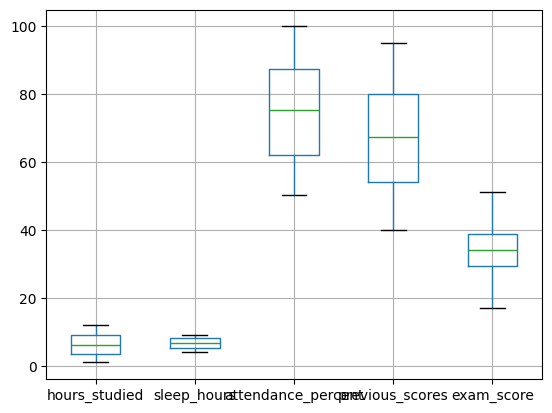

In [25]:
Stu.boxplot()
plt.show()